In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV


In [2]:
train = np.load("./data/processed/dataset_train_shortened.npz", allow_pickle=True)
X_train = train["X"]
y_train = train["y"]          # int {0,1}

full = np.load("./data/processed/dataset_full.npz", allow_pickle=True)
X_full = full["X"]
K0_full = full["K0"]


In [3]:
def run_supervised_pipeline(model, X_train, y_train, X_full):
    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)

    if hasattr(model, "predict_proba"):
        P_A = model.predict_proba(X_full)[:, 1]
    else:
        scores = model.decision_function(X_full)
        P_A = 1 / (1 + np.exp(-scores))

    return train_score, P_A


In [4]:
def mean_and_susceptibility_vs_K0(P_A, K0_full):
    df = pd.DataFrame({
        "K0": K0_full,
        "P_C": 1.0 - P_A
    })

    grouped = df.groupby("K0")["P_C"]

    mean_P_C = grouped.mean()
    chi_P_C = grouped.var()   # susceptibility

    return mean_P_C, chi_P_C


In [5]:
def extract_k0_crit(chi_series):
    """
    chi_series: pd.Series indexed by K0
    """
    k0_values = chi_series.index.values
    chi_values = chi_series.values

    idx_max = np.argmax(chi_values)
    return k0_values[idx_max], chi_values[idx_max]


In [6]:
tree_variants = {
    # (very simple, prone to single-feature dominance)
    "DT_depth1": DecisionTreeClassifier(
        max_depth=1,
        random_state=0
    ),

    # Slightly deeper
    "DT_depth2": DecisionTreeClassifier(
        max_depth=2,
        random_state=0
    ),

    # Sklearn default
    "DT_default": DecisionTreeClassifier(
        random_state=0
    ),

    # Regularized tree
    "DT_min_samples_leaf_50": DecisionTreeClassifier(
        min_samples_leaf=50,
        random_state=0
    ),
}


In [7]:
rf_variants = {
    # (shallow, brittle)
    "RF_depth1": RandomForestClassifier(
        n_estimators=200,
        max_depth=1,
        random_state=0
    ),

    # Weak learners, still shallow
    "RF_depth2": RandomForestClassifier(
        n_estimators=200,
        max_depth=2,
        random_state=0
    ),

    # Sklearn default
    "RF_default": RandomForestClassifier(
        n_estimators=200,
        random_state=0
    ),

    # Strong regularization
    "RF_min_samples_leaf_50": RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=50,
        random_state=0
    ),
}


In [8]:
def build_pipeline(model, calibrated):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", model)
    ])

    if not calibrated:
        return pipe

    return CalibratedClassifierCV(
        pipe,
        method="sigmoid",
        cv=3
    )


In [9]:
results = []

def run_experiment(model_dict, family_name):
    for name, base_model in model_dict.items():
        for calibrated in [False, True]:

            model = build_pipeline(base_model, calibrated)

            train_acc, P_A = run_supervised_pipeline(
                model, X_train, y_train, X_full
            )

            mean_P_C, chi_P_C = mean_and_susceptibility_vs_K0(P_A, K0_full)
            k0_crit, chi_max = extract_k0_crit(chi_P_C)

            results.append({
                "family": family_name,
                "model": name,
                "calibrated": calibrated,
                "train_acc": train_acc,
                "k0_crit": k0_crit,
                "chi_max": chi_max
            })

            print(
                f"{family_name:3s} | {name:25s} | "
                f"{'cal' if calibrated else 'raw'} | "
                f"acc={train_acc:.5f} | "
                f"k0_crit={k0_crit:.4f}"
            )


In [10]:
run_experiment(tree_variants, "DT")
run_experiment(rf_variants, "RF")

DT  | DT_depth1                 | raw | acc=1.00000 | k0_crit=4.7800
DT  | DT_depth1                 | cal | acc=1.00000 | k0_crit=4.7800
DT  | DT_depth2                 | raw | acc=1.00000 | k0_crit=4.7800
DT  | DT_depth2                 | cal | acc=1.00000 | k0_crit=4.7800
DT  | DT_default                | raw | acc=1.00000 | k0_crit=4.7800
DT  | DT_default                | cal | acc=1.00000 | k0_crit=4.7800
DT  | DT_min_samples_leaf_50    | raw | acc=1.00000 | k0_crit=4.7800
DT  | DT_min_samples_leaf_50    | cal | acc=1.00000 | k0_crit=4.7800
RF  | RF_depth1                 | raw | acc=1.00000 | k0_crit=4.7700
RF  | RF_depth1                 | cal | acc=1.00000 | k0_crit=4.7700
RF  | RF_depth2                 | raw | acc=1.00000 | k0_crit=4.7700
RF  | RF_depth2                 | cal | acc=1.00000 | k0_crit=4.7700
RF  | RF_default                | raw | acc=1.00000 | k0_crit=4.7700
RF  | RF_default                | cal | acc=1.00000 | k0_crit=4.7700
RF  | RF_min_samples_leaf_50    | 

In [11]:
df = pd.DataFrame(results)
print(df.sort_values(["family", "model", "calibrated"]))


   family                   model  calibrated  train_acc  k0_crit   chi_max
4      DT              DT_default       False        1.0     4.78  0.247173
5      DT              DT_default        True        1.0     4.78  0.181343
0      DT               DT_depth1       False        1.0     4.78  0.247173
1      DT               DT_depth1        True        1.0     4.78  0.181343
2      DT               DT_depth2       False        1.0     4.78  0.247173
3      DT               DT_depth2        True        1.0     4.78  0.181343
6      DT  DT_min_samples_leaf_50       False        1.0     4.78  0.247173
7      DT  DT_min_samples_leaf_50        True        1.0     4.78  0.181343
12     RF              RF_default       False        1.0     4.77  0.076658
13     RF              RF_default        True        1.0     4.77  0.181358
8      RF               RF_depth1       False        1.0     4.77  0.064840
9      RF               RF_depth1        True        1.0     4.77  0.175726
10     RF   

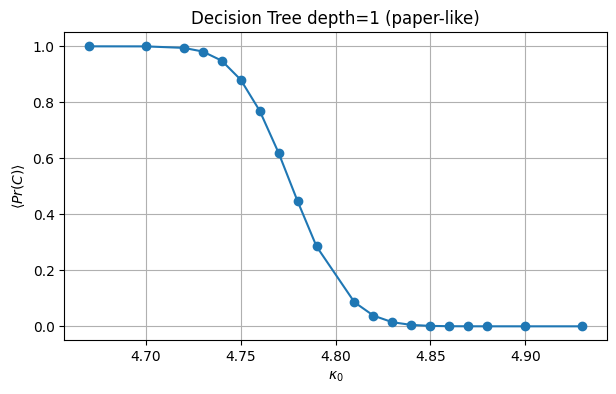

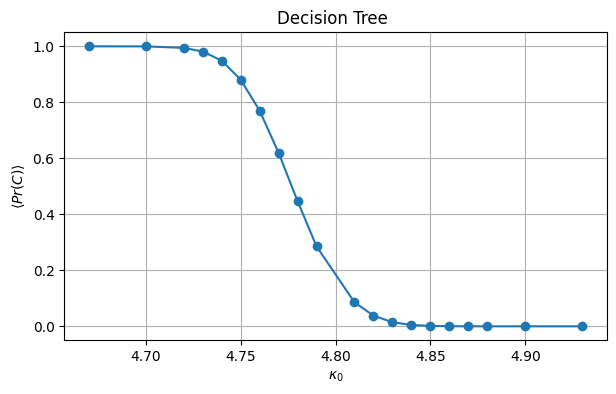

In [13]:
from matplotlib import pyplot as plt

def plot_tree_case(model, title):
    model = build_pipeline(model, calibrated=False)
    _, P_A = run_supervised_pipeline(model, X_train, y_train, X_full)
    mean_P_C, chi = mean_and_susceptibility_vs_K0(P_A, K0_full)

    plt.figure(figsize=(7,4))
    plt.plot(mean_P_C.index, mean_P_C.values, marker="o")
    plt.title(title)
    plt.xlabel(r"$\kappa_0$")
    plt.ylabel(r"$\langle Pr(C) \rangle$")
    plt.grid(True)
    plt.show()

plot_tree_case(
    DecisionTreeClassifier(max_depth=1, random_state=0),
    "Decision Tree depth=1 (paper-like)"
)
plot_tree_case(
    DecisionTreeClassifier(),
    "Decision Tree "
)

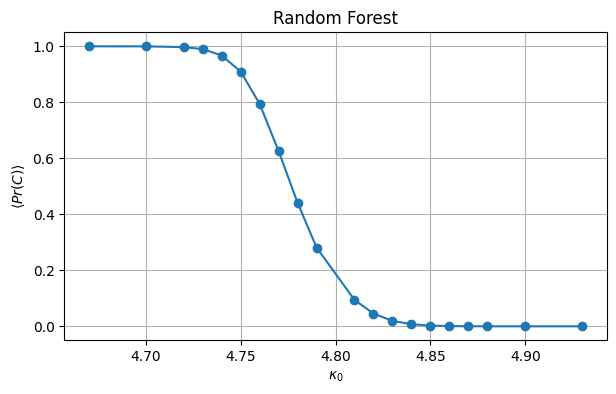

In [16]:
plot_tree_case(
    RandomForestClassifier(),
    "Random Forest"
)

In [18]:
dt_depth1 = DecisionTreeClassifier(
    max_depth=1,
    random_state=0
)

_, P_A = run_supervised_pipeline(
    dt_depth1,
    X_train,
    y_train,
    X_full
)

mean_P_C, chi = mean_and_susceptibility_vs_K0(P_A, K0_full)
k0_crit, _ = extract_k0_crit(chi)

print("DT depth=1 (paper-like extreme)")
print(f"k0_crit = {k0_crit:.4f}")


DT depth=1 (paper-like extreme)
k0_crit = 4.7800
